# DEG → Functional Enrichment

Pre-ranked GSEA on per-(sex × cell type) DEG CSVs followed by a side-by-side pathway heatmap.

All logic lives in `pygenelab.deg_functional_enrichment`. The DEG dict in **Cell A** drives everything — any number of cell types, either gender, any DEG source as long as the CSV has a gene column + signed log-fold-change + adjusted p-value.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

import pygenelab as pgl
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# ---------------------------------------------------------------------------
# Canonical condition × sex palette for ALL non-UMAP analysis plots.
# Edit here once and every Sankey / chord / heatmap downstream picks it up.
# UMAPs are explicitly excluded (scanpy palettes drive those).
# ---------------------------------------------------------------------------
SEX_CONDITION_PALETTE = {
    ('M', 'WT'): '#004a99',  # Control male
    ('M', 'KO'): '#90bff9',  # SkM-KO male
    ('F', 'WT'): '#f71480',  # Control female
    ('F', 'KO'): '#fa98c7',  # SkM-KO female
}

# Sex-only collapse (used when a plot isn't split by condition — picks WT shade).
SEX_PALETTE = {
    'F': SEX_CONDITION_PALETTE[('F', 'WT')],
    'M': SEX_CONDITION_PALETTE[('M', 'WT')],
}

# Make sure SVG text stays editable in Illustrator (text elements, not paths).
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": "none",
})
figure_params = {
    "dpi": 300,
    "bbox_inches": "tight",
    "format": "svg",
    "transparent": True,
}

## Cell A — pick the DEG files

`DEG_FILES` maps a label (used as the heatmap column) to a CSV path. Any sex / any cell type / any number of entries.

Each CSV must have:
- a gene column (the first column is auto-renamed to `GENE_COL`)
- a signed log-fold-change column (`LOG2FC_COL`)
- an adjusted p-value column (`PVAL_COL`)

In [5]:
# --- Sankey input: sex × fiber-type unfiltered KO DEGs (Seurat) ---
# Pre-ranked GSEA needs both signs to compute proper NES, so we load the
# unfiltered Seurat DEG CSVs and pick Up / Down genes from each by avg_log2FC
# sign based on DIRECTION_MODE. Flipping the toggle builds Up- vs Down-Sankey.
DIRECTION_MODE = "downregulated"   # "upregulated" -> log2FC > 0, "downregulated" -> log2FC < 0

SEURAT_TABLES = "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/Seurat_analysis_outputs/tables"
DEG_FILES = {
    "Fast2x_F": f"{SEURAT_TABLES}/Female_FastIIX_unfiltered_KO_DEGs_nmt.csv",
    "Fast2b_F": f"{SEURAT_TABLES}/Female_FastIIB_integrated_KO_DEGs_nmt.csv",
    "Fast2x_M": f"{SEURAT_TABLES}/Male_FastIIX_unfiltered_KO_DEGs_nmt.csv",
    "Fast2b_M": f"{SEURAT_TABLES}/Male_FastIIB_integrated_KO_DEGs_nmt.csv",
}
# Seurat column conventions (first column is unnamed gene index — auto-renamed to GENE_COL)
GENE_COL = "gene_name"
LOG2FC_COL = "avg_log2FC"
PVAL_COL = "p_val_adj"

if DIRECTION_MODE not in {"upregulated", "downregulated"}:
    raise ValueError("DIRECTION_MODE must be 'upregulated' or 'downregulated'")

ANALYSIS_LABEL = f"MF_FastIIX_FastIIB_{DIRECTION_MODE}"
SANKEY_DIRECTION = "Up" if DIRECTION_MODE == "upregulated" else "Down"

# --- Step 9 metabolism-heatmap input: scanpy-style KO-vs-WT DEGs ---
# Different DEG source from the Sankey: scanpy wilcoxon outputs (KO vs WT)
# stored per-sex / per-celltype, with logfoldchanges / pvals_adj column names.
HEATMAP_DEG_ROOT = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/DEGs"
HEATMAP_DEG_FILES = {
    "Fast2x_F": f"{HEATMAP_DEG_ROOT}/female/degs/DEGs_KO_vs_WT_Fast_IIX.csv",
    "Fast2b_F": f"{HEATMAP_DEG_ROOT}/female/degs/DEGs_KO_vs_WT_Fast_IIB.csv",
    "Fast2x_M": f"{HEATMAP_DEG_ROOT}/male/degs/DEGs_KO_vs_WT_Fast_IIX.csv",
    "Fast2b_M": f"{HEATMAP_DEG_ROOT}/male/degs/DEGs_KO_vs_WT_Fast_IIB.csv",
}
HEATMAP_LOG2FC_COL = "logfoldchanges"
HEATMAP_PVAL_COL = "pvals_adj"

# --- Female-only Fast IIX vs IIB (legacy sankey config) ---
# DEG_FILES = {
#     "IIX": f"{SEURAT_TABLES}/Female_FastIIX_unfiltered_KO_DEGs.csv",
#     "IIB": f"{SEURAT_TABLES}/Female_FastIIB_unfiltered_KO_DEGs.csv",
# }
# ANALYSIS_LABEL = "Female_FastIIX_FastIIB"

# --- Male-only Fast IIX vs IIB (legacy sankey config) ---
# DEG_FILES = {
#     "IIX": f"{SEURAT_TABLES}/Male_Fast IIX_unfiltered_KO_DEGs.csv",
#     "IIB": f"{SEURAT_TABLES}/Male_Fast IIB_unfiltered_KO_DEGs.csv",
# }
# ANALYSIS_LABEL = "Male_FastIIX_vs_FastIIB"

print(f"  DIRECTION_MODE     = {DIRECTION_MODE}")
print(f"  SANKEY_DIRECTION   = {SANKEY_DIRECTION}")
print(f"  ANALYSIS_LABEL     = {ANALYSIS_LABEL}")
print("  -- Sankey DEG files (Seurat) --")
for label, p in DEG_FILES.items():
    print(f"    {label:>10s}: {p}")
print("  -- Heatmap DEG files (scanpy) --")
for label, p in HEATMAP_DEG_FILES.items():
    print(f"    {label:>10s}: {p}")


  DIRECTION_MODE     = downregulated
  SANKEY_DIRECTION   = Down
  ANALYSIS_LABEL     = MF_FastIIX_FastIIB_downregulated
  -- Sankey DEG files (Seurat) --
      Fast2x_F: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/Seurat_analysis_outputs/tables/Female_FastIIX_unfiltered_KO_DEGs_nmt.csv
      Fast2b_F: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/Seurat_analysis_outputs/tables/Female_FastIIB_integrated_KO_DEGs_nmt.csv
      Fast2x_M: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/Seurat_analysis_outputs/tables/Male_FastIIX_unfiltered_KO_DEGs_nmt.csv
      Fast2b_M: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/Seurat_analysis_outputs/tables/Male_FastIIB_integrated_KO_DEGs_nmt.csv
  -- Heatmap DEG files (scanpy) --
      Fast2x_F: /ix/djishnu/Akanksha/datasets/ERCC1_KO/DEGs/female/degs/DEGs_KO_vs_WT_Fast_IIX.csv
      Fast2b_F: /ix/djishnu/Akanksha/datasets/ERCC1_KO/DEGs/female/degs/DEGs_KO_vs_WT_Fast_IIB.csv
      Fast2x_M: /ix/

## Cell B — pathway source

Pick the GMT and (optionally) keywords to restrict pathway names. The size filter keeps pathways with 15–500 genes by default.

In [6]:
# --- Mouse MSigDB (full) ---
PATHWAYS_GMT = "/ix/djishnu/Akanksha/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
# PSC: /ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt
GENE_ORIGIN = "mice"

# OUTPUT_DIR label. The Sankey runs against the full (size-filtered) pathway
# universe — no keyword restriction — so the LLM has the whole landscape to
# bucket into top-level KEGG-BRITE categories. The Step 9 metabolism heatmap
# does its own narrower filter (see METAB_HEATMAP_TERMS below).
PATHWAY_TYPE = "ALL"

PATHWAY_SIZE_MIN = 15
PATHWAY_SIZE_MAX = 500

# --- Step 9 heatmap: curated metabolism pathways × REACTOME / WP / HALLMARK ---
METAB_HEATMAP_TERMS = [
    "Fatty acid metabolism",
    "Xenobiotic metabolism",
    "Pyruvate metabolism",
    "Phospholipid metabolism",
    "Glycogen metabolism",
    "Glycosaminoglycan metabolism",
    "Purine metabolism",
    "Glucose metabolism",
    "Carbohydrate metabolism",
]
METAB_HEATMAP_DBS = ["REACTOME", "WP", "HALLMARK"]

## Output directory

In [7]:
PATHWAY_TYPE_LABEL = "_".join(PATHWAY_TYPE) if isinstance(PATHWAY_TYPE, (list, tuple)) else str(PATHWAY_TYPE)

OUTPUT_DIR = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output"
) / ANALYSIS_LABEL / PATHWAY_TYPE_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(OUTPUT_DIR)

/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output/MF_FastIIX_FastIIB_downregulated/ALL


## Step 1 — load DEG CSVs

In [8]:
# Sankey DEGs (Seurat: avg_log2FC / p_val_adj)
degs = pgl.load_deg_csvs(DEG_FILES, gene_col=GENE_COL)
for label, df in degs.items():
    print(f"  sankey  {label}: {df.shape[0]} genes, columns = {list(df.columns)}")

# Heatmap DEGs (scanpy: logfoldchanges / pvals_adj)
degs_heatmap = pgl.load_deg_csvs(HEATMAP_DEG_FILES, gene_col=GENE_COL)
for label, df in degs_heatmap.items():
    print(f"  heatmap {label}: {df.shape[0]} genes, columns = {list(df.columns)}")


  sankey  Fast2x_F: 8281 genes, columns = ['gene_name', 'p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj']
  sankey  Fast2b_F: 837 genes, columns = ['gene_name', 'p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj']
  sankey  Fast2x_M: 7840 genes, columns = ['gene_name', 'p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj']
  sankey  Fast2b_M: 713 genes, columns = ['gene_name', 'p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj']
  heatmap Fast2x_F: 4000 genes, columns = ['gene_name', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'cell_type']
  heatmap Fast2b_F: 4000 genes, columns = ['gene_name', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'cell_type']
  heatmap Fast2x_M: 4000 genes, columns = ['gene_name', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'cell_type']
  heatmap Fast2b_M: 4000 genes, columns = ['gene_name', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'cell_type']


## Step 2 — pre-ranked gene lists per DEG file

Ranking = signed log-fold-change × −log10(adjusted p-value).

In [9]:
RANK_TOP_N = 500  # cap genes per cell type fed to GSEA (top-N by |signed score|)

ranked_lists = {
    label: pgl.create_ranked_genelist(
        df,
        log2fc_col=LOG2FC_COL,
        pval_col=PVAL_COL,
        gene_col=GENE_COL,
        top_n=RANK_TOP_N,
    )
    for label, df in degs.items()
}
for label, r in ranked_lists.items():
    print(f"  {label}: ranked shape = {r.shape}")

  Fast2x_F: ranked shape = (1, 500)
  Fast2b_F: ranked shape = (1, 500)
  Fast2x_M: ranked shape = (1, 500)
  Fast2b_M: ranked shape = (1, 500)


## Step 3 — load + filter pathways

In [10]:
pathways_all = pgl.convert_gmt_to_decoupler_format(PATHWAYS_GMT, gene_origin=GENE_ORIGIN)
pathways = pgl.filter_pathways(
    pathways_all,
    size_min=PATHWAY_SIZE_MIN,
    size_max=PATHWAY_SIZE_MAX,
)
print(f"  pathways retained (size-filtered, no keyword restriction): {pathways['source'].nunique()}")

  pathways retained (size-filtered, no keyword restriction): 9835


## Step 4 — GSEA per DEG file

In [11]:
gsea_results = {label: pgl.run_gsea(r, pathways) for label, r in ranked_lists.items()}
for label, res in gsea_results.items():
    print(f"{label}: {res.shape[0]} pathways scored")
    display(res.head(3))

Fast2x_F: 2018 pathways scored


,source,score,pval
0,BRUINS_UVC_RESPONSE_VIA_TP53_GROUP_D,1.907951,0.0
1,GOBP_SARCOMERE_ORGANIZATION,-1.816021,0.0
2,DESCARTES_ORGANOGENESIS_MYOCYTES,-1.879020,0.0


Fast2b_F: 2189 pathways scored


,source,score,pval
0,chr11B1,1.514312,0.0
1,ZFP709_TARGET_GENES,-1.512855,0.0
2,MIR_7057_3P,1.511597,0.0


Fast2x_M: 2036 pathways scored


,source,score,pval
0,WP_IL3_SIGNALING_PATHWAY,-1.870187,0.0
1,HALLMARK_MYOGENESIS,1.689859,0.0
2,GOCC_EXTRINSIC_COMPONENT_OF_MEMBRANE,-1.790584,0.0


Fast2b_M: 1266 pathways scored


,source,score,pval
0,MIR_211_5P,-1.514964,0.0
1,MIR_7670_3P,-1.514964,0.0
2,GOBP_REGULATION_OF_FILOPODIUM_ASSEMBLY,-1.531934,0.0


## Step 5 — annotate + dedup pathway terms

In [12]:
plot_dfs = {
    label: pgl.dedup_by_simplified_term(pgl.prepare_gsea_plot_df(res))
    for label, res in gsea_results.items()
}
for label, df in plot_dfs.items():
    print(f"  {label}: {df.shape[0]} unique simplified terms")

  Fast2x_F: 950 unique simplified terms
  Fast2b_F: 957 unique simplified terms
  Fast2x_M: 994 unique simplified terms
  Fast2b_M: 553 unique simplified terms


## Step 7 — LLM-categorize shared pathways enriched in Fast IIX (Up) → CSV

Buckets every shared, Up-direction pathway in `plot_dfs["IIX"]` into KEGG-BRITE-style top-level categories (Metabolism / Genetic Information Processing / Environmental Information Processing / Cellular Processes / Organismal Systems / Cancer related / Other) using the Claude API. This is a mouse dataset, so disease-named pathways are routed into `Organismal Systems`, except cancer/tumor/oncogene-named ones which land in `Cancer related`. Strips the DB prefix, keeps score/pval, and writes a CSV suitable for a downstream Sankey (DB → category → pathway).

Requires `anthropic` SDK and the `ANTHROPIC_API_KEY` env var. Set `SANKEY_LABEL` / `SANKEY_DIRECTION` to switch cell type or direction.

In [36]:
# import os
# from pathlib import Path

# # Load Anthropic API key from a file outside the repo (one line, key only).
# # Create it once: `echo "sk-ant-..." > ~/.anthropic_key && chmod 600 ~/.anthropic_key`
# ANTHROPIC_KEY_FILE = Path("~/.anthropic_api_key").expanduser()
# os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_KEY_FILE.read_text().strip()
# print(f"  loaded ANTHROPIC_API_KEY from {ANTHROPIC_KEY_FILE}")

In [13]:
SANKEY_LABEL = "Fast2x_F"   # which entry in plot_dfs to pool for this single-label CSV
# SANKEY_DIRECTION is inherited from Cell A (derived from DIRECTION_MODE)
CATEGORIZE_MODEL = "claude-haiku-4-5-20251001"

# Explicit API toggle — you choose. No auto-detection.
#   USE_API = False -> read the cached CSV (raises if missing)
#   USE_API = True  -> call the Claude API and (over)write the cached CSV
USE_API = False


def _categorized_csv_path(label, direction):
    return OUTPUT_DIR / f"{ANALYSIS_LABEL}_{PATHWAY_TYPE_LABEL}_{label}_{direction}_categorized.csv"


def categorize_with_cache(plot_df, *, shared, direction, label, use_api):
    """Per-label LLM categorization with an explicit API/cache switch.

    `use_api=False` reads the cached CSV at `_categorized_csv_path(label, direction)`
    and raises `FileNotFoundError` if it's missing. `use_api=True` calls
    `pgl.categorize_enriched_plot_df` and writes the result to that CSV
    (overwriting any existing file). No silent fallback either way.
    """
    csv_path = _categorized_csv_path(label, direction)
    if not use_api:
        if not csv_path.exists():
            raise FileNotFoundError(
                f"USE_API=False but no cached CSV at {csv_path}.\n"
                "Set USE_API=True once to populate it."
            )
        print(f"  cache read  -> {csv_path.name}")
        return pd.read_csv(csv_path)
    df = pgl.categorize_enriched_plot_df(
        plot_df,
        shared=shared,
        direction=direction,
        model=CATEGORIZE_MODEL,
    )
    df.to_csv(csv_path, index=False)
    print(f"  api call    -> saved {csv_path.name}")
    return df


shared = pgl.common_pathways(plot_dfs)
print(f"  shared pathways across all labels: {len(shared)}")

sankey_df = categorize_with_cache(
    plot_dfs[SANKEY_LABEL],
    shared=shared,
    direction=SANKEY_DIRECTION,
    label=SANKEY_LABEL,
    use_api=USE_API,
)
print(f"  {SANKEY_LABEL} {SANKEY_DIRECTION}-enriched (shared) pathways: {len(sankey_df)}")
print(sankey_df["category"].value_counts())
sankey_df.head(10)


  shared pathways across all labels: 329
  cache read  -> MF_FastIIX_FastIIB_downregulated_ALL_Fast2x_F_Down_categorized.csv
  Fast2x_F Down-enriched (shared) pathways: 95
category
Cellular Processes                      39
Organismal Systems                      30
Environmental Information Processing    13
Metabolism                               8
Genetic Information Processing           5
Name: count, dtype: int64


,Term,stripped_label,Gene_set,category,Group,score,pval,-log10(pval)
0,GOBP_NEGATIVE_REGULATION_OF_LOCOMOTION,NEGATIVE REGULATION OF LOCOMOTION,GOBP,Cellular Processes,Down,-1.829032,0.000000,300.000000
1,GOBP_SARCOMERE_ORGANIZATION,SARCOMERE ORGANIZATION,GOBP,Cellular Processes,Down,-1.816021,0.000000,300.000000
2,GOBP_CELLULAR_COMPONENT_ASSEMBLY_INVOLVED_IN_M...,CELLULAR COMPONENT ASSEMBLY INVOLVED IN MORPHO...,GOBP,Cellular Processes,Down,-1.830285,0.722779,0.140994
3,GOBP_NON_MEMBRANE_BOUNDED_ORGANELLE_ASSEMBLY,NON MEMBRANE BOUNDED ORGANELLE ASSEMBLY,GOBP,Cellular Processes,Down,-1.534499,0.790056,0.102342
4,GOBP_REGULATION_OF_BINDING,REGULATION OF BINDING,GOBP,Cellular Processes,Down,-1.646755,0.790056,0.102342
5,GOBP_CALCIUM_ION_HOMEOSTASIS,CALCIUM ION HOMEOSTASIS,GOBP,Cellular Processes,Down,-1.571483,0.790056,0.102342
6,GOBP_SEQUESTERING_OF_CALCIUM_ION,SEQUESTERING OF CALCIUM ION,GOBP,Cellular Processes,Down,-1.734280,0.790056,0.102342
7,GOBP_MAINTENANCE_OF_LOCATION_IN_CELL,MAINTENANCE OF LOCATION IN CELL,GOBP,Cellular Processes,Down,-1.734280,0.790056,0.102342
8,GOBP_ENDOTHELIAL_CELL_PROLIFERATION,ENDOTHELIAL CELL PROLIFERATION,GOBP,Cellular Processes,Down,-1.272079,0.803273,0.095137
9,GOBP_TAXIS,TAXIS,GOBP,Cellular Processes,Down,-1.318547,0.803273,0.095137


## Step 8 — Sankey: per-list enriched pathways → LLM categories

For each label in `plot_dfs` (e.g. IIX, IIB), pool the shared `SANKEY_DIRECTION`-enriched pathways, classify each via the Claude API, and render a two-column Sankey:

- **Left bar** = source DEG list (one stack per cell type / fiber type).
- **Right bar** = KEGG-BRITE-style top-level category.
- **Flow width** = number of enriched pathways from that list mapped to that category.

Rebuilds the per-label categorized frames inline (independent of Step 7's single-label CSV), then calls `pgl.plot_sankey`.

  cache read  -> MF_FastIIX_FastIIB_downregulated_ALL_Fast2b_F_Down_categorized.csv
  cache read  -> MF_FastIIX_FastIIB_downregulated_ALL_Fast2x_F_Down_categorized.csv
  cache read  -> MF_FastIIX_FastIIB_downregulated_ALL_Fast2b_M_Down_categorized.csv
  cache read  -> MF_FastIIX_FastIIB_downregulated_ALL_Fast2x_M_Down_categorized.csv
  rows fed to sankey: 551
category  Cancer related  Cellular Processes  \
Source                                         
Fast2b_F               0                  62   
Fast2b_M               1                  41   
Fast2x_F               0                  39   
Fast2x_M               0                  16   

category  Environmental Information Processing  \
Source                                           
Fast2b_F                                    31   
Fast2b_M                                    29   
Fast2x_F                                    13   
Fast2x_M                                    22   

category  Genetic Information Processing  Metabo

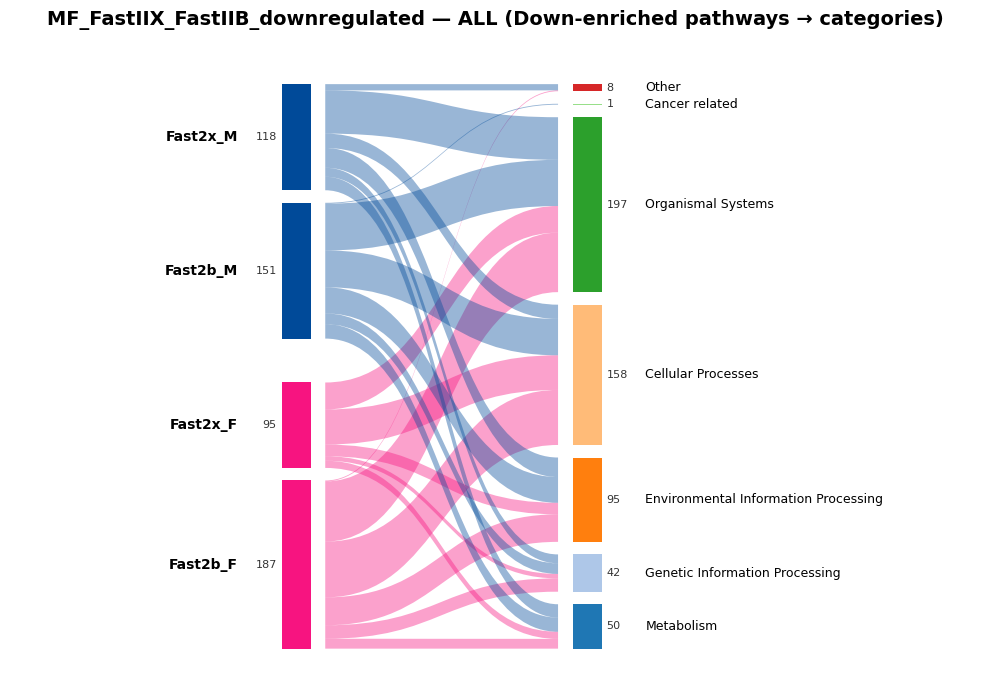

In [14]:
SANKEY_LABELS = list(plot_dfs.keys())   # e.g. ["Fast2x_F", "Fast2b_F", "Fast2x_M", "Fast2b_M"]
# SANKEY_DIRECTION inherits from Cell A; USE_API, categorize_with_cache, and
# CATEGORIZE_MODEL come from Step 7 (run that cell first to set USE_API).

# Visual order on the left bar (top -> bottom): Fast2x_M, Fast2b_M, Fast2x_F, Fast2b_F.
# plot_sankey stacks from the bottom up, so the list is reversed (first entry = bottom).
SANKEY_LEFT_ORDER = ["Fast2b_F", "Fast2x_F", "Fast2b_M", "Fast2x_M"]

# Each DEG list is a SkM-KO vs WT comparison; condition is the comparison axis,
# not a split axis. So the left bar splits sex x fiber only, and both fibers
# within a sex share the WT (saturated) shade of the canonical SEX_CONDITION_PALETTE.
left_colors = {
    label: SEX_CONDITION_PALETTE[(label.rsplit("_", 1)[-1], "WT")]
    for label in SANKEY_LEFT_ORDER
}

shared = pgl.common_pathways(plot_dfs)

sankey_frames = []
for label in SANKEY_LEFT_ORDER:
    df_lab = categorize_with_cache(
        plot_dfs[label],
        shared=shared,
        direction=SANKEY_DIRECTION,
        label=label,
        use_api=USE_API,
    )
    df_lab = df_lab.assign(Source=label)
    sankey_frames.append(df_lab)

sankey_long = pd.concat(sankey_frames, ignore_index=True)
print(f"  rows fed to sankey: {len(sankey_long)}")
print(sankey_long.groupby(["Source", "category"]).size().unstack(fill_value=0))

# Spacing knobs:
#   left_gap          -> small vertical gap between Fast2b_* and Fast2x_* within a sex
#   left_group_gap    -> larger gap inserted between the F-block and the M-block
#   left_group_indices=[1] -> apply the larger gap *after* index 1 (Fast2x_F),
#                             i.e. between Fast2x_F and Fast2b_M (F | M boundary)
#   right_gap         -> vertical gap between adjacent category bars on the right
#   flow_pad          -> horizontal whitespace between the bars and the ribbons
sankey_fig, sankey_ax = pgl.plot_sankey(
    sankey_long,
    left_col="Source",
    right_col="category",
    left_order=SANKEY_LEFT_ORDER,
    right_order=pgl.PATHWAY_TOP_CATEGORIES,
    left_colors=left_colors,
    title=f"{ANALYSIS_LABEL} — {PATHWAY_TYPE_LABEL} ({SANKEY_DIRECTION}-enriched pathways → categories)",
    show_counts=True,
    left_gap=0.02,
    left_group_gap=0.07,
    left_group_indices=[1],
    right_gap=0.02,
    flow_pad=0.015,
)
sankey_fig.savefig(
    OUTPUT_DIR / f"{ANALYSIS_LABEL}_{PATHWAY_TYPE_LABEL}_{SANKEY_DIRECTION}_sankey.svg",
    **figure_params,
)


## Step 9 — Heatmap of curated metabolism pathways (full DEG list, no top-N cap)

Independent of the Sankey pipeline. Filters `pathways_all` down to a curated metabolism set — `METAB_HEATMAP_TERMS` matched across `METAB_HEATMAP_DBS` (REACTOME / WP / HALLMARK) — and re-runs pre-ranked GSEA against **all DEGs** per Fast IIB / Fast IIX (no `RANK_TOP_N` cap). Renders the two-panel Up (red) / Down (blue) `-log10(pval)` heatmap as in the historical `Enriched_Pathways.ipynb` (commit `eaed757`).

In [ ]:
# Wipe any stale figures from previous runs so the cell starts with a clean
# pyplot manager (otherwise re-running can stack extra renders at cell end).
plt.close("all")

# ---- 1. curate metabolism pathways across REACTOME / WP / HALLMARK ---------
def _term_variants(term):
    """Underscore-uppercase variants of an '<X> metabolism' phrase to match
    both HALLMARK/WP form (X_METABOLISM) and REACTOME form (METABOLISM_OF_X[S])."""
    parts = term.upper().replace("-", "_").split()
    if parts and parts[-1].rstrip("S") == "METABOLISM":
        body = "_".join(parts[:-1])
        return [
            f"{body}_METABOLISM",
            f"METABOLISM_OF_{body}",
            f"METABOLISM_OF_{body}S",
        ]
    return ["_".join(parts)]

_metab_variants = sorted({v for t in METAB_HEATMAP_TERMS for v in _term_variants(t)})

def _is_metab_pathway(name):
    upper = name.upper()
    db = upper.split("_", 1)[0]
    if db not in METAB_HEATMAP_DBS:
        return False
    return any(v in upper for v in _metab_variants)

metab_sources = sorted({s for s in pathways_all["source"].unique() if _is_metab_pathway(s)})
print(f"  curated metabolism pathways retained: {len(metab_sources)}")
for s in metab_sources:
    print(f"    - {s}")

pathways_metab = pathways_all[pathways_all["source"].isin(metab_sources)].copy()


def _clean_metab_label(term):
    """Drop the DB prefix (HALLMARK_/WP_/REACTOME_/etc.) and the 'metabolism'
    boilerplate from a pathway term, then title-case for readability.

    Examples:
      HALLMARK_FATTY_ACID_METABOLISM -> 'Fatty Acid'
      WP_PYRUVATE_METABOLISM         -> 'Pyruvate'
      REACTOME_METABOLISM_OF_PURINES -> 'Purines'
    """
    s = str(term).upper()
    for db in METAB_HEATMAP_DBS:
        if s.startswith(f"{db}_"):
            s = s[len(db) + 1:]
            break
    if s.startswith("METABOLISM_OF_"):
        s = s[len("METABOLISM_OF_"):]
    if s.endswith("_METABOLISM"):
        s = s[: -len("_METABOLISM")]
    elif s == "METABOLISM":
        s = "metabolism"
    return s.replace("_", " ").title()


# Per-sex y-tick exclusions: substrings (case-insensitive) — any cleaned
# pathway label containing one of these is dropped from that sex's heatmap.
PATHWAY_EXCLUDE_PER_SEX = {
    "F": {"glucose"},   # drop Glucose pathway from the female heatmap
    "M": set(),
}


# ---- 2. one heatmap per sex (so pathways enriched only in F or only in M
#         aren't dropped by the cross-sex common_pathways intersection) -----
# Each heatmap keeps the original two-panel layout: Up pathways on top,
# Down pathways below. Inline backend auto-renders exactly the figures
# created here at cell end (one for F, one for M).
heatmap_groups = {
    "F": {k: v for k, v in degs_heatmap.items() if k.endswith("_F")},
    "M": {k: v for k, v in degs_heatmap.items() if k.endswith("_M")},
}

heatmap_figs = {}
for sex_label, degs_subset in heatmap_groups.items():
    if not degs_subset:
        print(f"  [skip] no DEG files for sex={sex_label}")
        continue

    print(f"\n=== heatmap: sex={sex_label} ({len(degs_subset)} labels) ===")

    ranked_lists_full = {
        label: pgl.create_ranked_genelist(
            df,
            log2fc_col=HEATMAP_LOG2FC_COL,
            pval_col=HEATMAP_PVAL_COL,
            gene_col=GENE_COL,
            top_n=None,
        )
        for label, df in degs_subset.items()
    }
    for label, r in ranked_lists_full.items():
        print(f"  {label} (uncapped): ranked shape = {r.shape}")

    gsea_results_metab = {label: pgl.run_gsea(r, pathways_metab) for label, r in ranked_lists_full.items()}

    plot_dfs_metab = {
        label: pgl.dedup_by_simplified_term(pgl.prepare_gsea_plot_df(res))
        for label, res in gsea_results_metab.items()
    }
    # Rename Term to drop DB prefix + metabolism boilerplate, so the heatmap
    # y-tick labels read e.g. "Fatty Acid" instead of "HALLMARK_FATTY_ACID_METABOLISM".
    plot_dfs_metab = {
        label: df.assign(Term=df["Term"].map(_clean_metab_label))
        for label, df in plot_dfs_metab.items()
    }
    for label, df in plot_dfs_metab.items():
        print(f"  {label}: {df.shape[0]} unique simplified metab terms")

    shared_metab = pgl.common_pathways(plot_dfs_metab)

    # Apply sex-specific y-tick exclusions (substring match, case-insensitive)
    excludes = {e.lower() for e in PATHWAY_EXCLUDE_PER_SEX.get(sex_label, set())}
    if excludes:
        before = len(shared_metab)
        shared_metab = [
            p for p in shared_metab
            if not any(e in str(p).lower() for e in excludes)
        ]
        print(f"  excluded for {sex_label} ({sorted(excludes)}): {before - len(shared_metab)} pathway(s) dropped")

    print(f"  shared metab pathways across {sex_label} labels: {len(shared_metab)}")

    fig, panels = pgl.plot_pathway_heatmap(
        plot_dfs_metab,
        pathways=shared_metab,
        title=f"{ANALYSIS_LABEL} — curated metabolism pathways ({sex_label})",
    )
    fig.savefig(OUTPUT_DIR / f"{ANALYSIS_LABEL}_metab_heatmap_{sex_label}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{ANALYSIS_LABEL}_metab_heatmap_{sex_label}.svg", bbox_inches="tight")
    heatmap_figs[sex_label] = fig
